# Cost Generator

This notebook develops a pipeline for generating realistic inbound and outbound lane costs
(fixed and variable) for synthetic supply-chain networks. It takes pre-computed distances
(from `distance_generator.ipynb`) and SKU weights (from `weight_generator.ipynb`) as inputs and
then generates costs that depend on lane distance while preserving the natural correlation
between fixed and variable costs through joint modelling via a Gaussian Mixture Model (GMM)
in log-space.

### Pipeline overview

| Step | Description | Output |
|------|-------------|--------|
| **1** | Setup and Data Loading | - |
| **2** | Exploratory Data Analysis | - |
| **3** | Build calibration dataset & log-transform | Transformed $z = (x, y_f, y_v)^\top$ |
| **4** | Fit 3-D GMM and select optimal $K$ via BIC | Calibrated GMM parameters per direction |
| **5** | Conditional cost sampling given distance | Cost matrices that match the distance |
| **6** | Testing and Validation | - |

## 1. Setup & Data Loading

### 1.1 Configuration

In [1]:
# CONFIGURATION

# Seed
SEED = 42

# Data path
RAW_DATA_PATH = "../../../data_files/raw"

# Output paths
OUTPUTS_PATH = "outputs/intermediate"
MODELS_PATH = "outputs/generated_models"

# Network dimensions (must match preceding generators)
n_regions = 10
n_warehouses = 10
n_skus = 10

# GMM calibration
K_MAX = 10                  
N_INIT = 10                 
COV_TYPE = "full"           

# Generation safeguards
N_SAMPLES_TEST = 5000       
CLIP_PERCENTILE = (1, 99)   
EPS = 1e-6                  


### 1.2 Imports & Data Loading

In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.mixture import GaussianMixture
from scipy.stats import norm, ks_2samp, cramervonmises_2samp, anderson_ksamp, pearsonr
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

rng = np.random.default_rng(SEED)

In [3]:
path = Path(RAW_DATA_PATH)

outbound_raw_df = pd.read_csv(path / "03_warehouse_to_region.csv")
inbound_raw_df  = pd.read_csv(path / "05_supplier_to_warehouse.csv")

print(f"Outbound lanes (warehouse -> region): {len(outbound_raw_df):>6,}")
print(f"Inbound lanes  (supplier -> warehouse): {len(inbound_raw_df):>6,}")

Outbound lanes (warehouse -> region):  1,311
Inbound lanes  (supplier -> warehouse): 12,547


### 1.3 Load Pre-computed Inputs from Preceding Pipeline Steps

Load the outputs from `distance_generator.ipynb` and `weight_generator.ipynb`.
Run those notebooks first to create the files in the `outputs/` folder.

In [5]:
# LOAD INPUTS

# Set paths
outputs_dir = Path("outputs/intermediate")
dist_path = outputs_dir / f"distances_n{n_regions}_w{n_warehouses}_s{n_skus}.npz"
weights_path = outputs_dir / f"sku_weights_n{n_skus}.npy"

# Check paths exist
if not dist_path.exists():
    raise FileNotFoundError(
        f"{dist_path} not found. Run distance_generator.ipynb first."
    )
if not weights_path.exists():
    raise FileNotFoundError(
        f"{weights_path} not found. Run weight_generator.ipynb first."
    )

# Load distances & selected indices
dist_data = np.load(dist_path)
outbound_distances = dist_data["outbound_distances"]
inbound_distances = dist_data["inbound_distances"]
sku_indices = dist_data["sku_indices"].tolist()

# Load SKU weights
sku_weights = np.load(weights_path)

# Shape checks
assert outbound_distances.shape == (n_warehouses, n_regions), \
    f"outbound_distances shape {outbound_distances.shape} != ({n_warehouses}, {n_regions})"
assert inbound_distances.shape == (n_warehouses, n_skus), \
    f"inbound_distances shape {inbound_distances.shape} != ({n_warehouses}, {n_skus})"
assert sku_weights.shape == (n_skus,), \
    f"sku_weights shape {sku_weights.shape} != ({n_skus},)"
assert len(sku_indices) == n_skus, \
    f"sku_indices length {len(sku_indices)} != {n_skus}"

# Print results
print(f"Loaded from {outputs_dir}/")
print(f"  Outbound distances: {outbound_distances.shape}  range [{outbound_distances.min():.1f}, {outbound_distances.max():.1f}] km")
print(f"  Inbound distances:  {inbound_distances.shape}  range [{inbound_distances.min():.1f}, {inbound_distances.max():.1f}] km")
print(f"  SKU weights:        {sku_weights.shape}  range [{sku_weights.min():.2f}, {sku_weights.max():.2f}] kg")
print(f"  SKU indices:        {len(sku_indices)} SKUs")


Loaded from outputs\intermediate/
  Outbound distances: (10, 10)  range [239.7, 17201.0] km
  Inbound distances:  (10, 10)  range [282.3, 10111.5] km
  SKU weights:        (10,)  range [0.99, 30.41] kg
  SKU indices:        10 SKUs


## 2. Exploratory Data Analysis

Before building the generator, we examine the joint distribution of distance,
fixed cost, and variable cost for both outbound and inbound lanes in the real data.

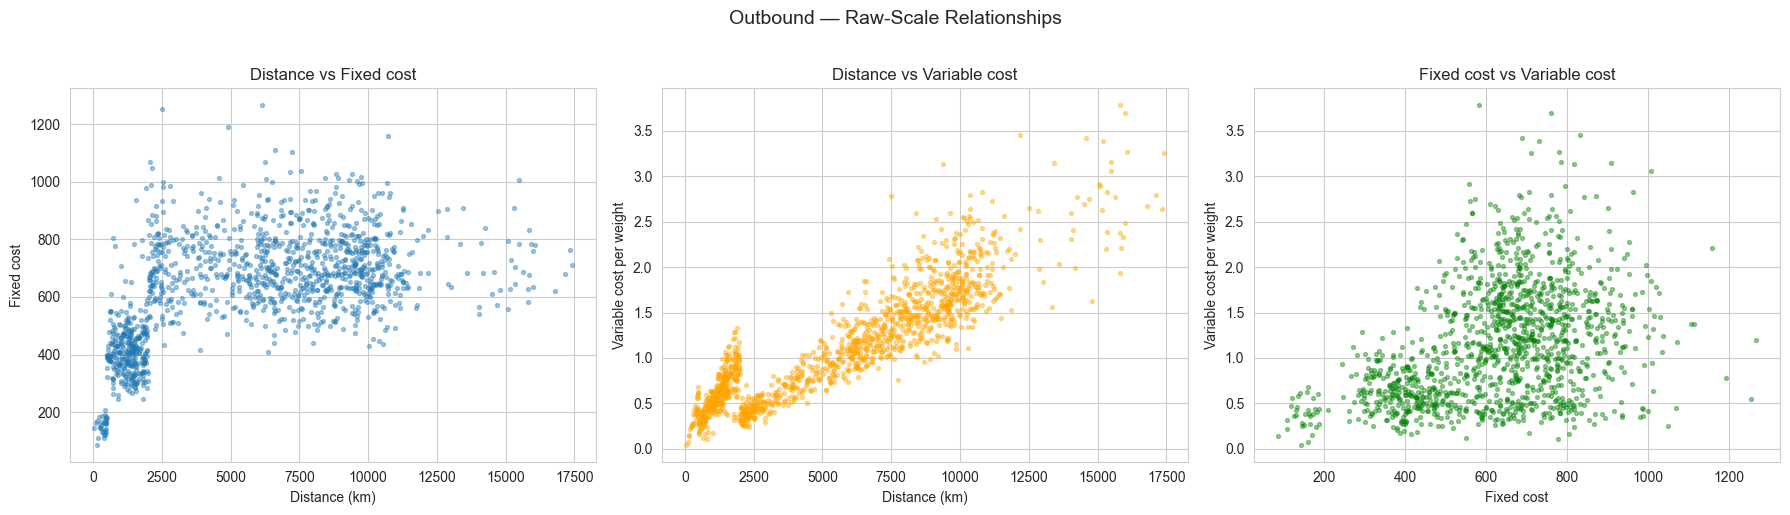

-------------------------------------------------------
Outbound Summary
-------------------------------------------------------
  Distance   min: 40.2  max: 17426.0  mean: 5761.2
  Fixed      min: 86.27  max: 1266.45  mean: 630.18
  Variable   min: 0.0457  max: 3.7796  mean: 1.1459

-------------------------------------------------------
Outbound Pearson Correlations
-------------------------------------------------------
  dist-fix: 0.542  dist-var: 0.897  fix-var: 0.386


In [6]:
# OUTBOUND LANES

# Get distances and costs
d   = outbound_raw_df["distance_km"].values
c_f = outbound_raw_df["fixed_costs"].values
c_v = outbound_raw_df["variable_costs_per_weight"].values

# Compute correlation
r_df, _ = pearsonr(d, c_f)
r_dv, _ = pearsonr(d, c_v)
r_fv, _ = pearsonr(c_f, c_v)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Outbound — Raw-Scale Relationships", fontsize=14, y=1.02)

axes[0].scatter(d, c_f, s=8, alpha=0.4)
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Fixed cost")
axes[0].set_title("Distance vs Fixed cost")

axes[1].scatter(d, c_v, s=8, alpha=0.4, color="orange")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Variable cost per weight")
axes[1].set_title("Distance vs Variable cost")

axes[2].scatter(c_f, c_v, s=8, alpha=0.4, color="green")
axes[2].set_xlabel("Fixed cost")
axes[2].set_ylabel("Variable cost per weight")
axes[2].set_title("Fixed cost vs Variable cost")

plt.tight_layout()
plt.show()

# Print results
print("-"*55)
print("Outbound Summary")
print("-"*55)
print(f"  Distance   min: {d.min():.1f}  max: {d.max():.1f}  mean: {d.mean():.1f}")
print(f"  Fixed      min: {c_f.min():.2f}  max: {c_f.max():.2f}  mean: {c_f.mean():.2f}")
print(f"  Variable   min: {c_v.min():.4f}  max: {c_v.max():.4f}  mean: {c_v.mean():.4f}\n")
print("-"*55)
print("Outbound Pearson Correlations")
print("-"*55)
print(f"  dist-fix: {r_df:.3f}  dist-var: {r_dv:.3f}  fix-var: {r_fv:.3f}")


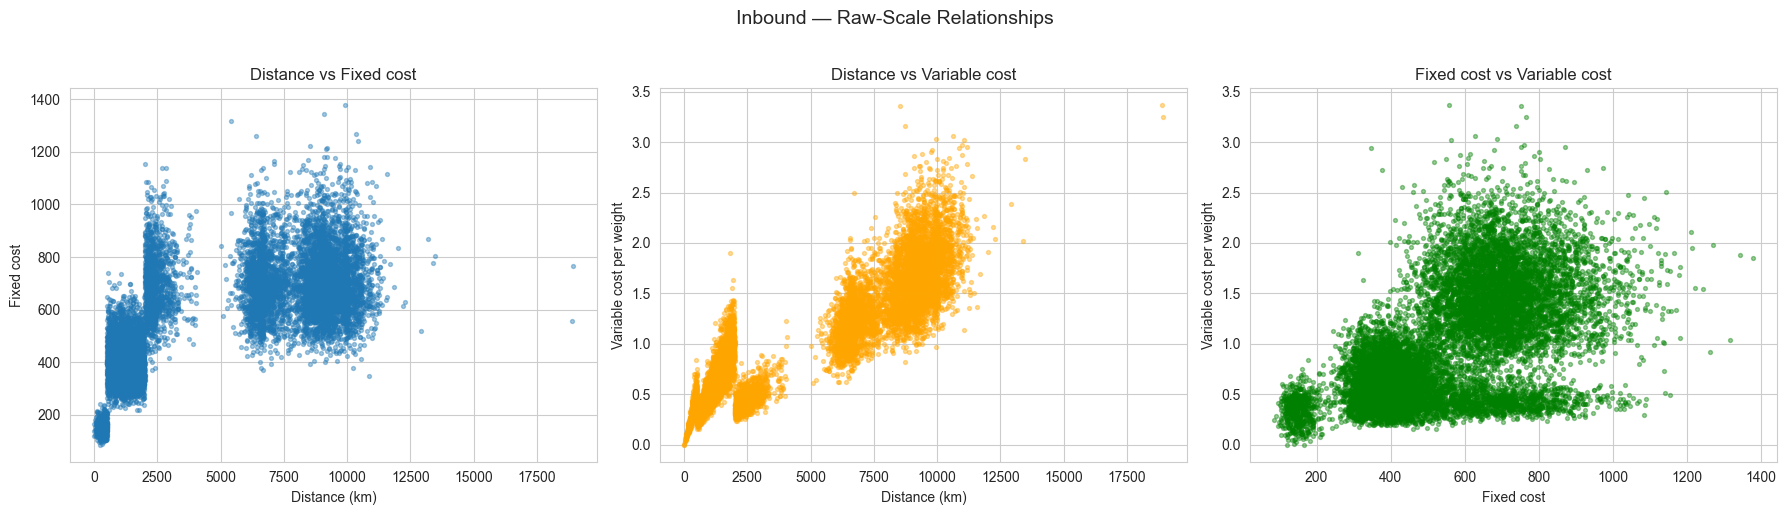

-------------------------------------------------------
Inbound Summary
-------------------------------------------------------
  Distance   min: 0.0  max: 18916.0  mean: 4529.6
  Fixed      min: 85.73  max: 1377.20  mean: 559.63
  Variable   min: 0.0000  max: 3.3644  mean: 1.0029

-------------------------------------------------------
Inbound Pearson Correlations
-------------------------------------------------------
  dist-fix: 0.705  dist-var: 0.900  fix-var: 0.561


In [7]:
# INBOUND LANES

# Get distances and costs
d   = inbound_raw_df["distance_km"].values
c_f = inbound_raw_df["fixed_costs"].values
c_v = inbound_raw_df["variable_costs_per_weight"].values

# Compute correlation
r_df, _ = pearsonr(d, c_f)
r_dv, _ = pearsonr(d, c_v)
r_fv, _ = pearsonr(c_f, c_v)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Inbound — Raw-Scale Relationships", fontsize=14, y=1.02)

axes[0].scatter(d, c_f, s=8, alpha=0.4)
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Fixed cost")
axes[0].set_title("Distance vs Fixed cost")

axes[1].scatter(d, c_v, s=8, alpha=0.4, color="orange")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Variable cost per weight")
axes[1].set_title("Distance vs Variable cost")

axes[2].scatter(c_f, c_v, s=8, alpha=0.4, color="green")
axes[2].set_xlabel("Fixed cost")
axes[2].set_ylabel("Variable cost per weight")
axes[2].set_title("Fixed cost vs Variable cost")

plt.tight_layout()
plt.show()

# Print results
print("-"*55)
print("Inbound Summary")
print("-"*55)
print(f"  Distance   min: {d.min():.1f}  max: {d.max():.1f}  mean: {d.mean():.1f}")
print(f"  Fixed      min: {c_f.min():.2f}  max: {c_f.max():.2f}  mean: {c_f.mean():.2f}")
print(f"  Variable   min: {c_v.min():.4f}  max: {c_v.max():.4f}  mean: {c_v.mean():.4f}\n")
print("-"*55)
print("Inbound Pearson Correlations")
print("-"*55)
print(f"  dist-fix: {r_df:.3f}  dist-var: {r_dv:.3f}  fix-var: {r_fv:.3f}")

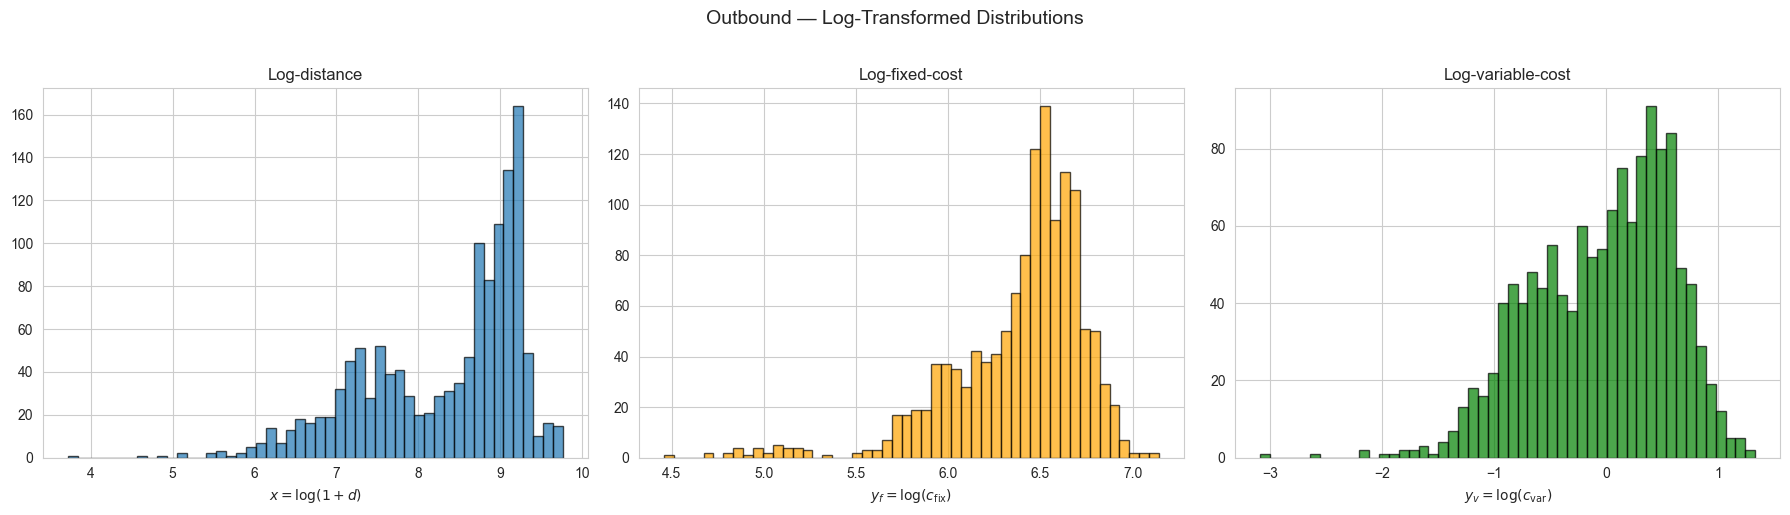

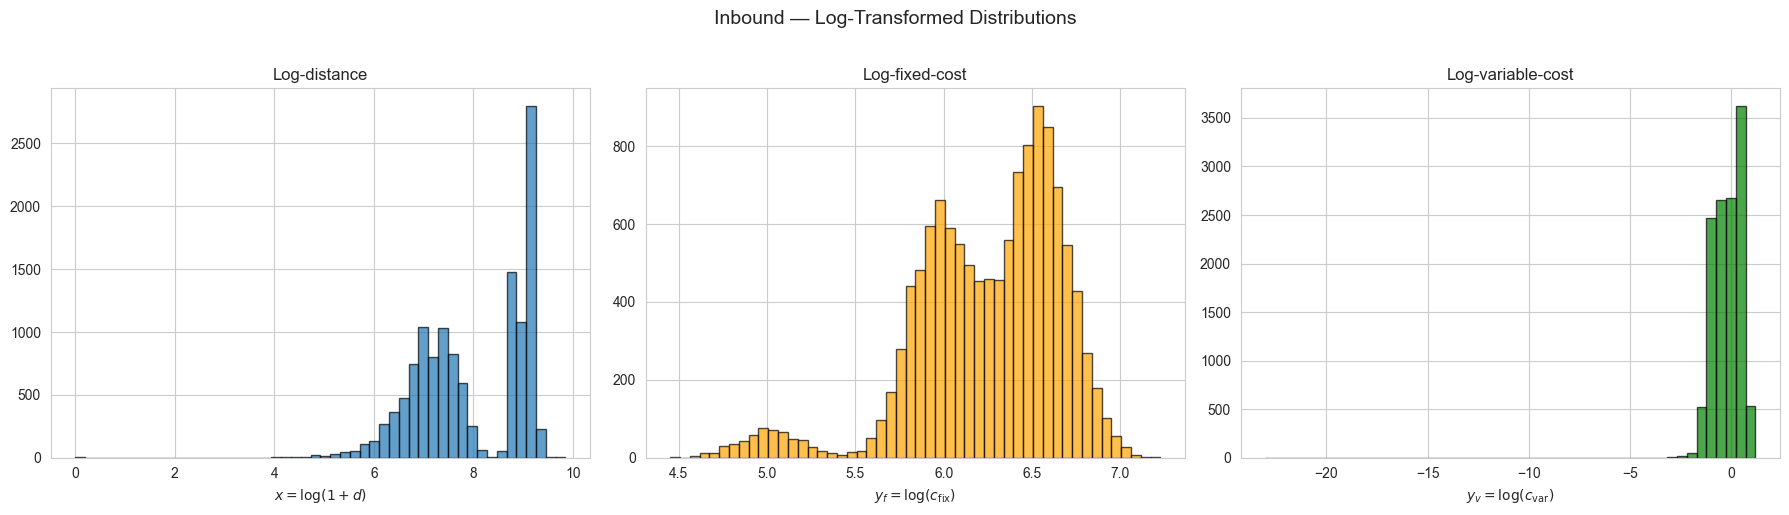

In [8]:
# LOG-SCALE DISTRIBUTIONS

# Plots
for label, df in [("Outbound", outbound_raw_df), ("Inbound", inbound_raw_df)]:
    x   = np.log1p(df["distance_km"].values)
    y_f = np.log(df["fixed_costs"].values)
    c_v = np.maximum(df["variable_costs_per_weight"].values, 1e-10)
    y_v = np.log(c_v)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{label} — Log-Transformed Distributions", fontsize=14, y=1.02)

    axes[0].hist(x,   bins=50, edgecolor="k", alpha=0.7)
    axes[0].set_xlabel(r"$x = \log(1+d)$")
    axes[0].set_title("Log-distance")

    axes[1].hist(y_f, bins=50, edgecolor="k", alpha=0.7, color="orange")
    axes[1].set_xlabel(r"$y_f = \log(c_{\mathrm{fix}})$")
    axes[1].set_title("Log-fixed-cost")

    axes[2].hist(y_v, bins=50, edgecolor="k", alpha=0.7, color="green")
    axes[2].set_xlabel(r"$y_v = \log(c_{\mathrm{var}})$")
    axes[2].set_title("Log-variable-cost")

    plt.tight_layout()
    plt.show()

## 3. Build Calibration Dataset

For each direction (outbound / inbound) and each real lane $i$, collect
$d_i$, $c_{\text{fix},i}$, $c_{\text{var},i}$ and compute the
log-transformed triple:

$$
z_i = \bigl(\,\log(1+d_i),\;\log(c_{\text{fix},i}),\;\log(c_{\text{var},i})\,\bigr)^\top
$$

In [9]:
# HELPERS

def _build_z(df: pd.DataFrame) -> np.ndarray:
    x   = np.log1p(df["distance_km"].values)
    y_f = np.log(df["fixed_costs"].values)
    c_v = np.maximum(df["variable_costs_per_weight"].values, 1e-10)
    y_v = np.log(c_v)
    return np.column_stack([x, y_f, y_v])

In [10]:
# BUILD CALIBRATION DATA

# Build the triples
z_outbound = _build_z(outbound_raw_df)
z_inbound  = _build_z(inbound_raw_df)

# Print results
print(f"Outbound calibration matrix: {z_outbound.shape}")
print(f"Inbound  calibration matrix: {z_inbound.shape}")

Outbound calibration matrix: (1311, 3)
Inbound  calibration matrix: (12547, 3)


## 4. Fit 3-D Gaussian Mixture Model (GMM)

We fit a 3-dimensional GMM on the computed $z_i$ and sample using its PDF:
$$
z \sim \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mu_k, \Sigma_k)
$$

To select the optimal number of components $K^*$, we fit the model for $K \in \{1, \dots, K_{\max}\}$ and select $K^*$ by minimizing BIC. We also consider AIC as a secondary check.

In [11]:
# HELPERS

def fit_best_gmm(
    z: np.ndarray,
    k_max: int,
    n_init: int,
    cov_type: str,
    seed: int
) -> tuple:
    """
    Fits GMMs for K=1..k_max and returns the model with lowest BIC.

    Args:
        z (np.ndarray): Calibration data. Shape: (n_lanes, 3).
        k_max (int): Maximum number of mixture components to try.
        n_init (int): Number of random initializations per K.
        cov_type (str): Covariance type for GaussianMixture.
        seed (int): Random seed.

    Returns:
        best_gmm (GaussianMixture): Fitted model with optimal K.
        results (list[dict]): Per-K diagnostics (bic, aic, log_likelihood, k).
    """
    results = []
    best_bic = np.inf
    best_gmm = None

    for k in range(1, k_max + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov_type,
            n_init=n_init,
            max_iter=500,
            random_state=seed,
        )
        gmm.fit(z)
        bic = gmm.bic(z)
        aic = gmm.aic(z)
        ll  = gmm.score(z) * len(z)
        results.append({"k": k, "bic": bic, "aic": aic, "log_likelihood": ll})

        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm

    return best_gmm, results

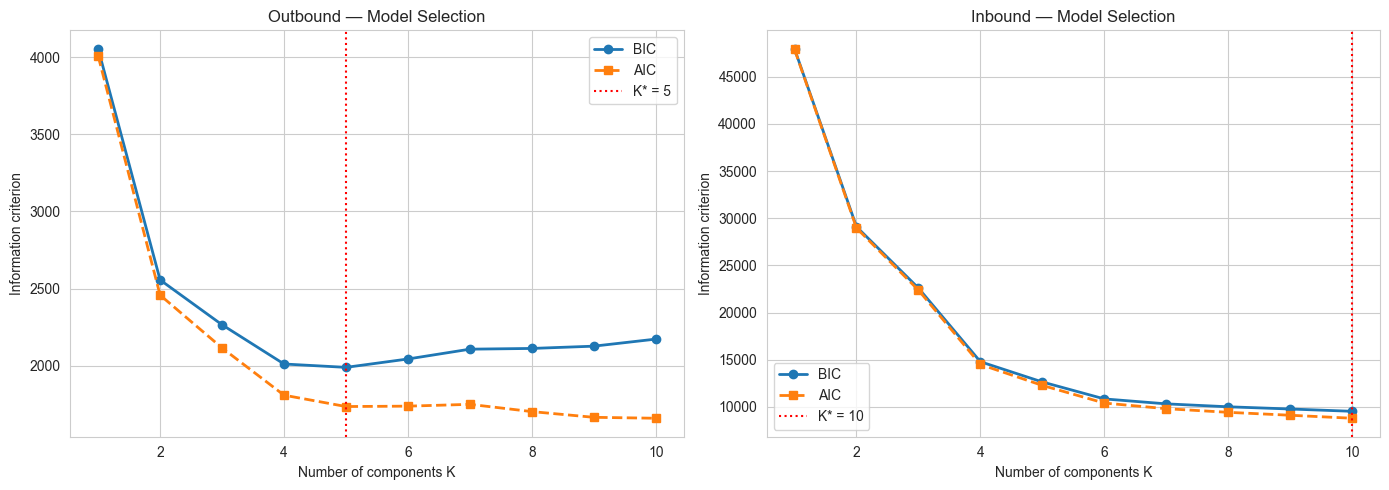

Outbound: best K = 5 (BIC = 1990.2)
Inbound:  best K = 10 (BIC = 9525.3)


In [12]:
# FIT OUTBOUND AND INBOUND GMM

# Fit outbound GMM
gmm_outbound, results_outbound = fit_best_gmm(
    z_outbound, K_MAX, N_INIT, COV_TYPE, SEED
)

# Fit inbound GMM
gmm_inbound, results_inbound = fit_best_gmm(
    z_inbound, K_MAX, N_INIT, COV_TYPE, SEED
)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, gmm, label in [
    (axes[0], results_outbound, gmm_outbound, "Outbound"),
    (axes[1], results_inbound,  gmm_inbound,  "Inbound"),
]:
    ks   = [r["k"] for r in results]
    bics = [r["bic"] for r in results]
    aics = [r["aic"] for r in results]

    ax.plot(ks, bics, "o-", label="BIC", linewidth=2)
    ax.plot(ks, aics, "s--", label="AIC", linewidth=2)
    ax.axvline(gmm.n_components, color="red", linestyle=":", label=f"K* = {gmm.n_components}")
    ax.set_xlabel("Number of components K")
    ax.set_ylabel("Information criterion")
    ax.set_title(f"{label} — Model Selection")
    ax.legend()

plt.tight_layout()
plt.show()

# Print results
print(f"Outbound: best K = {gmm_outbound.n_components} (BIC = {gmm_outbound.bic(z_outbound):.1f})")
print(f"Inbound:  best K = {gmm_inbound.n_components} (BIC = {gmm_inbound.bic(z_inbound):.1f})")

In [13]:
# SAVE FITTED MODELS TO generated_models

# Create path
MODELS_PATH = Path("outputs/generated_models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Save model
with open(MODELS_PATH / "costs_gmm_outbound.pkl", "wb") as f:
    pickle.dump(gmm_outbound, f)
with open(MODELS_PATH / "costs_gmm_inbound.pkl", "wb") as f:
    pickle.dump(gmm_inbound, f)
print(f"Saved costs_gmm_outbound.pkl and costs_gmm_inbound.pkl to {MODELS_PATH}/")

Saved costs_gmm_outbound.pkl and costs_gmm_inbound.pkl to outputs\generated_models/


In [14]:
# GMM PARAMETERS

for label, gmm in [("Outbound", gmm_outbound), ("Inbound", gmm_inbound)]:
    print(f"\n{'='*55}")
    print(f"  {label} GMM (K={gmm.n_components})")
    print(f"{'='*55}")
    for k in range(gmm.n_components):
        print(f"  Component {k+1}:")
        print(f"    weight  pi_k  = {gmm.weights_[k]:.4f}")
        print(f"    mean    mu_k  = {gmm.means_[k]}")
        print(f"    cov diag      = {np.diag(gmm.covariances_[k])}")


  Outbound GMM (K=5)
  Component 1:
    weight  pi_k  = 0.5647
    mean    mu_k  = [9.02645709 6.55509583 0.40019185]
    cov diag      = [0.07131631 0.02985669 0.09791625]
  Component 2:
    weight  pi_k  = 0.1588
    mean    mu_k  = [ 7.28296196  5.99573203 -0.33756773]
    cov diag      = [0.03790526 0.03642355 0.07215725]
  Component 3:
    weight  pi_k  = 0.1828
    mean    mu_k  = [ 8.01668906  6.55575067 -0.63438666]
    cov diag      = [0.1449794  0.03241464 0.16963717]
  Component 4:
    weight  pi_k  = 0.0684
    mean    mu_k  = [ 6.65461952  5.99263736 -0.92310183]
    cov diag      = [0.05919018 0.0299517  0.10913893]
  Component 5:
    weight  pi_k  = 0.0252
    mean    mu_k  = [ 5.76654913  5.0125474  -1.09898188]
    cov diag      = [0.29247287 0.03513948 0.34019969]

  Inbound GMM (K=10)
  Component 1:
    weight  pi_k  = 0.0862
    mean    mu_k  = [ 6.52178366  5.98072906 -1.09122065]
    cov diag      = [0.03051646 0.0337856  0.06133798]
  Component 2:
    weight  pi

## 5. Conditional Cost Sampling

Given a lane distance $d$, we generate *correlated* fixed and variable costs $(c_{\text{fix}}, c_{\text{var}})$ from the fitted 3D-GMM on $(x,y_f,y_v)$, where $x=\log(1+d)$, $y_f=\log(c_{\text{fix}})$, and $y_v=\log(c_{\text{var}})$.

1. **Log-distance transform**:
   Compute $x = \log(1+d)$ to match the calibration data. The $\log(1+d)$ transform avoids $\log(0)$ for $d=0$ and stabilizes behaviour at short distances.
2. **Posterior component weights**  
   For each component $k$, compute its weights given $x$ and normalize across $k=1,...,K$: 

   $$
   p(k\mid x)=\frac{\pi_k\,\mathcal{N}\!\left(x;\mu_{k,x},\Sigma_{k,xx}\right)}{\sum_{j=1}^K \pi_j\,\mathcal{N}\!\left(x;\mu_{j,x},\Sigma_{j,xx}\right)}.
   $$

   This uses the marginal density of $x$ in each component to weight how likely that component is given the observed distance.

3. **Sample component**: Sample $k \sim \text{Categorical}(p(1|x), \dots, p(K|x))$. This selects which component's conditional distribution we use for the cost pair.

4. **Sample $(y_f,y_v)\mid x,k$ via Gaussian conditioning**  
   Let $\bm{y}=(y_f,y_v)^\top$. Partition the component mean and covariance as
   $$
   \mu_k=\begin{pmatrix}\mu_{k,x}\\ \mu_{k,\bm{y}}\end{pmatrix},\qquad
   \Sigma_k=\begin{pmatrix}
   \Sigma_{k,xx} & \Sigma_{k,x\bm{y}}\\
   \Sigma_{k,\bm{y}x} & \Sigma_{k,\bm{y}\bm{y}}
   \end{pmatrix},
   $$
   where $\mu_{k,x}\in\mathbb{R}$, $\mu_{k,\bm{y}}\in\mathbb{R}^2$, $\Sigma_{k,xx}\in\mathbb{R}^{1\times 1}$, $\Sigma_{k,\bm{y}\bm{y}}\in\mathbb{R}^{2\times 2}$, $\Sigma_{k,x\bm{y}}\in\mathbb{R}^{1\times 2}$, and $\Sigma_{k,\bm{y}x}\in\mathbb{R}^{2\times 1} = \Sigma_{k,x\bm{y}}^\top$.  

   Then the conditional distribution is
   $$
   y\mid x,k \sim \mathcal{N}\!\left(
   \mu_{\text{cond}},\;
   \Sigma_{\text{cond}}
   \right).
   $$

   where 
   $$
   \mu_{\text{cond}} = \mu_{k,\bm{y}}+\Sigma_{k,\bm{y}x}\Sigma_{k,xx}^{-1}(x-\mu_{k,x}), \;
   \Sigma_{\text{cond}} = \Sigma_{k,\bm{y}\bm{y}}-\Sigma_{k,\bm{y}x}\Sigma_{k,xx}^{-1}\Sigma_{k,x\bm{y}}
   $$

   Standard Gaussian conditioning preserves the correlation structure between fixed and variable costs encoded in the component covariance.

5. **Back-transform**:
   Map from log back to original scale:
      $$
      c_{\text{fix}} = e^{y_f}, 
      c_{\text{var}} = e^{y_v}
      $$
   Generated costs are clipped to the calibration percentiles to avoid pathological outliers.

In [15]:
# HELPERS

def sample_costs(
    distances: np.ndarray,
    gmm: GaussianMixture,
    rng: np.random.Generator,
    eps: float = 1e-6,
    clip_lo: float = None,
    clip_hi_fix: float = None,
    clip_hi_var: float = None
) -> tuple:
    """
    Generates correlated (c_fix, c_var) for each distance via conditional GMM sampling.

    Args:
        distances (np.ndarray): Lane distances in km. Shape: (n,).
        gmm (GaussianMixture): Calibrated 3-D GMM on z = (log(1+d), log(c_fix), log(c_var)).
        rng (np.random.Generator): Random number generator.
        eps (float): Regularization for covariance inversion.
        clip_lo (float or None): Lower clipping bound for costs.
        clip_hi_fix (float or None): Upper clipping bound for fixed costs.
        clip_hi_var (float or None): Upper clipping bound for variable costs.

    Returns:
        c_fix (np.ndarray): Generated fixed costs. Shape: (n,).
        c_var (np.ndarray): Generated variable costs per weight. Shape: (n,).
    """
    distances = np.asarray(distances, dtype=float).ravel()
    n = len(distances)
    K = gmm.n_components
    c_fix = np.empty(n)
    c_var = np.empty(n)

    for i in range(n):
        x = np.log1p(distances[i])                                   

        # Posterior weights p(k | x)
        unnorm = np.array([
            gmm.weights_[k] * norm.pdf(
                x, loc=gmm.means_[k, 0],
                scale=np.sqrt(gmm.covariances_[k, 0, 0] + eps)
            )
            for k in range(K)
        ])
        total = unnorm.sum()
        posteriors = np.ones(K) / K if total < 1e-300 else unnorm / total

        k = rng.choice(K, p=posteriors)                               

        # GEN.4 — conditional (y_f, y_v) | x, k via Gaussian conditioning
        mu = gmm.means_[k]
        S  = gmm.covariances_[k]
        S_xx_inv = 1.0 / (S[0, 0] + eps)
        diff = x - mu[0]
        mu_cond  = mu[1:] + S[1:, 0] * S_xx_inv * diff
        cov_cond = S[1:, 1:] - np.outer(S[1:, 0], S[0, 1:]) * S_xx_inv

        cov_cond = (cov_cond + cov_cond.T) / 2 + eps * np.eye(2)
        y = rng.multivariate_normal(mu_cond, cov_cond)

        c_fix[i] = np.exp(y[0])                                     
        c_var[i] = np.exp(y[1])

    if clip_hi_fix is not None:
        c_fix = np.clip(c_fix, clip_lo, clip_hi_fix)
    if clip_hi_var is not None:
        c_var = np.clip(c_var, clip_lo, clip_hi_var)

    return c_fix, c_var

In [16]:
# COMPUTE CLIPPING BOUNDS

# Extract clip percentiles
# lo_pct, hi_pct = CLIP_PERCENTILE
lo_pct, hi_pct = (0, 100) # No clipping for now

# Clip outbound
clip_lo_out     = 0.0
clip_hi_fix_out = np.percentile(outbound_raw_df["fixed_costs"].values, hi_pct)
clip_hi_var_out = np.percentile(outbound_raw_df["variable_costs_per_weight"].values, hi_pct)

# Clip inbound
clip_lo_in     = 0.0
clip_hi_fix_in = np.percentile(inbound_raw_df["fixed_costs"].values, hi_pct)
clip_hi_var_in = np.percentile(inbound_raw_df["variable_costs_per_weight"].values, hi_pct)

# Print results
print(f"Outbound clip: c_fix [0, {clip_hi_fix_out:.2f}]  c_var: [0, {clip_hi_var_out:.4f}]")
print(f"Inbound  clip: c_fix [0, {clip_hi_fix_in:.2f}]  c_var: [0, {clip_hi_var_in:.4f}]")

Outbound clip: c_fix [0, 1266.45]  c_var: [0, 3.7796]
Inbound  clip: c_fix [0, 1377.20]  c_var: [0, 3.3644]


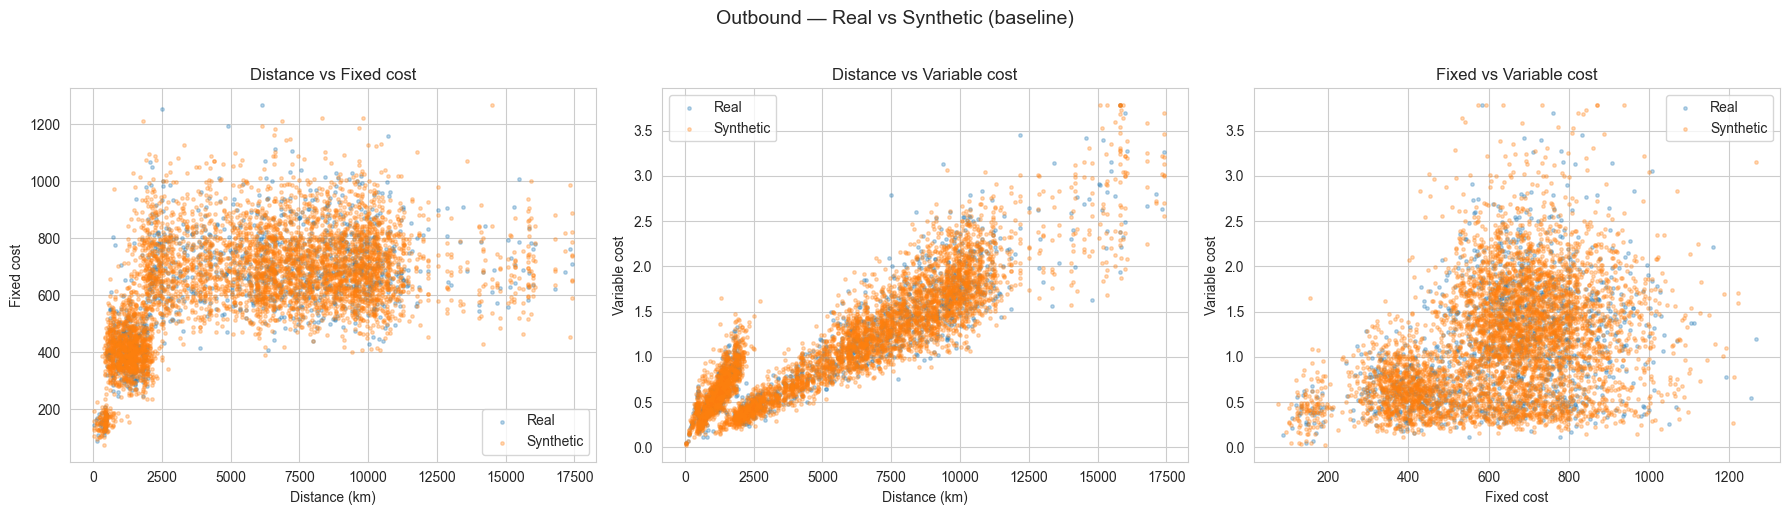

In [17]:
# SAMPLE OUTBOUND

# Sample outbound costs
d_out_test = rng.choice(outbound_raw_df["distance_km"].values, size=N_SAMPLES_TEST)
cf_out_base, cv_out_base = sample_costs(
    d_out_test, gmm_outbound, rng, EPS,
    clip_lo=clip_lo_out, clip_hi_fix=clip_hi_fix_out, clip_hi_var=clip_hi_var_out
)

# Get real values
d_real   = outbound_raw_df["distance_km"].values
cf_real  = outbound_raw_df["fixed_costs"].values
cv_real  = outbound_raw_df["variable_costs_per_weight"].values

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Outbound — Real vs Synthetic (baseline)", fontsize=14, y=1.02)

axes[0].scatter(d_real, cf_real, s=6, alpha=0.3, label="Real")
axes[0].scatter(d_out_test, cf_out_base, s=6, alpha=0.3, label="Synthetic")
axes[0].set_xlabel("Distance (km)"); axes[0].set_ylabel("Fixed cost")
axes[0].set_title("Distance vs Fixed cost"); axes[0].legend()

axes[1].scatter(d_real, cv_real, s=6, alpha=0.3, label="Real")
axes[1].scatter(d_out_test, cv_out_base, s=6, alpha=0.3, label="Synthetic")
axes[1].set_xlabel("Distance (km)"); axes[1].set_ylabel("Variable cost")
axes[1].set_title("Distance vs Variable cost"); axes[1].legend()

axes[2].scatter(cf_real, cv_real, s=6, alpha=0.3, label="Real")
axes[2].scatter(cf_out_base, cv_out_base, s=6, alpha=0.3, label="Synthetic")
axes[2].set_xlabel("Fixed cost"); axes[2].set_ylabel("Variable cost")
axes[2].set_title("Fixed vs Variable cost"); axes[2].legend()

plt.tight_layout()
plt.show()

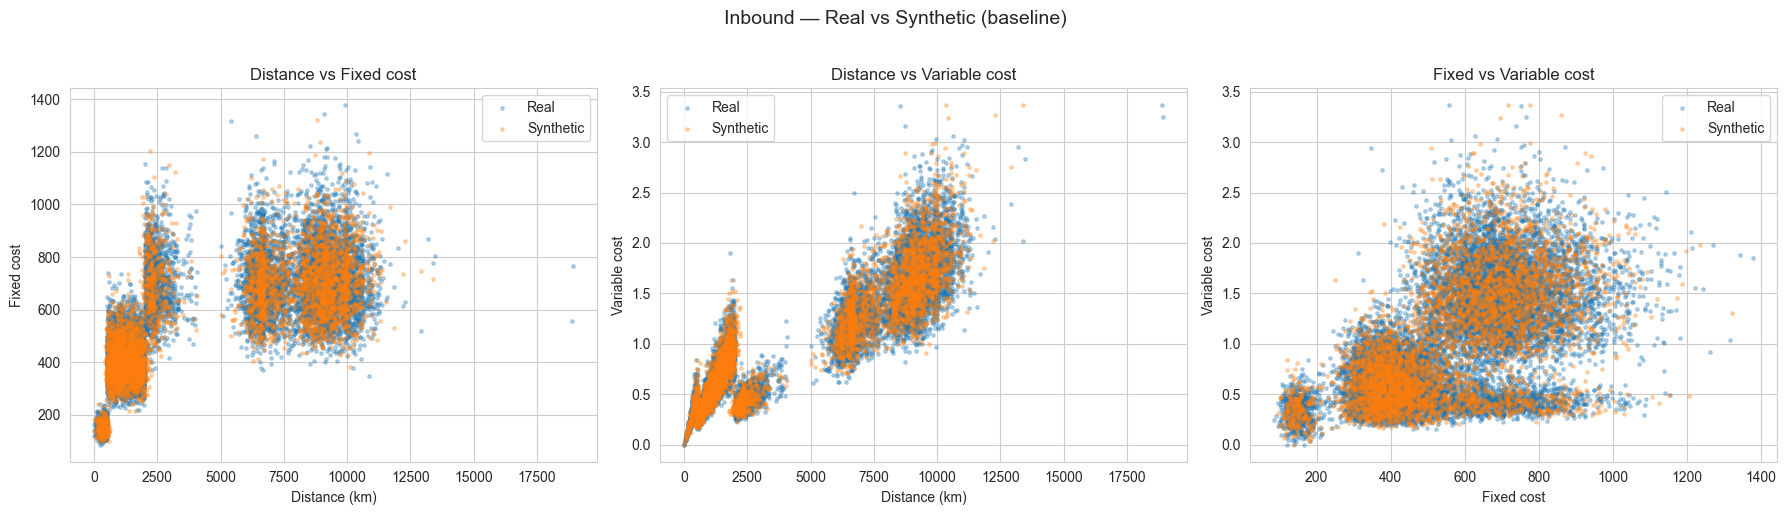

In [18]:
# SAMPLE INBOUND

# Sample inbound costs
d_in_test = rng.choice(inbound_raw_df["distance_km"].values, size=N_SAMPLES_TEST)
cf_in_base, cv_in_base = sample_costs(
    d_in_test, gmm_inbound, rng, EPS,
    clip_lo=clip_lo_in, clip_hi_fix=clip_hi_fix_in, clip_hi_var=clip_hi_var_in
)

# Get real values
d_real   = inbound_raw_df["distance_km"].values
cf_real  = inbound_raw_df["fixed_costs"].values
cv_real  = inbound_raw_df["variable_costs_per_weight"].values

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Inbound — Real vs Synthetic (baseline)", fontsize=14, y=1.02)

axes[0].scatter(d_real, cf_real, s=6, alpha=0.3, label="Real")
axes[0].scatter(d_in_test, cf_in_base, s=6, alpha=0.3, label="Synthetic")
axes[0].set_xlabel("Distance (km)"); axes[0].set_ylabel("Fixed cost")
axes[0].set_title("Distance vs Fixed cost"); axes[0].legend()

axes[1].scatter(d_real, cv_real, s=6, alpha=0.3, label="Real")
axes[1].scatter(d_in_test, cv_in_base, s=6, alpha=0.3, label="Synthetic")
axes[1].set_xlabel("Distance (km)"); axes[1].set_ylabel("Variable cost")
axes[1].set_title("Distance vs Variable cost"); axes[1].legend()

axes[2].scatter(cf_real, cv_real, s=6, alpha=0.3, label="Real")
axes[2].scatter(cf_in_base, cv_in_base, s=6, alpha=0.3, label="Synthetic")
axes[2].set_xlabel("Fixed cost"); axes[2].set_ylabel("Variable cost")
axes[2].set_title("Fixed vs Variable cost"); axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Testing & Validation

We systematically test the cost generator against the real data with summary
statistics, visual diagnostics, formal statistical tests, and scalability
analysis.

### 6.1 Summary Statistics Comparison

Compare mean, median, std, and key percentiles between the real data and the cost generator for both inbound/outbound and fixed/variable. Additionally, print the correlation between fixed and variable costs for real and synthetic data. 

In [19]:
# SUMMARY STATISTICS COMPARISON

# Sample and print summary stats
for label, raw_df, gmm, cl_lo, cl_hf, cl_hv in [
    ("Outbound", outbound_raw_df, gmm_outbound,
     clip_lo_out, clip_hi_fix_out, clip_hi_var_out),
    ("Inbound",  inbound_raw_df,  gmm_inbound,
     clip_lo_in,  clip_hi_fix_in,  clip_hi_var_in),
]:
    n_gen = len(raw_df)
    d_syn = rng.choice(raw_df["distance_km"].values, size=n_gen)
    cf_syn, cv_syn = sample_costs(d_syn, gmm, rng, EPS, cl_lo, cl_hf, cl_hv)

    cf_real = raw_df["fixed_costs"].values
    cv_real = raw_df["variable_costs_per_weight"].values

    print(f"\n{'='*55}")
    print(f"  {label} Summary Statistics")
    print(f"{'='*55}")
    for name, real, syn in [("Fixed cost", cf_real, cf_syn),
                             ("Variable cost", cv_real, cv_syn)]:
        print(f"-"*55)
        print(f"  {name}:")

        print(f"{'':>15s} {'Real':>12s} {'Synthetic':>12s}")
        print(f"{'Mean':>15s} {real.mean():>12.4f} {syn.mean():>12.4f}")
        print(f"{'Std':>15s} {real.std():>12.4f} {syn.std():>12.4f}")
        print(f"{'Median':>15s} {np.median(real):>12.4f} {np.median(syn):>12.4f}")
        print(f"{'Min':>15s} {real.min():>12.4f} {syn.min():>12.4f}")
        print(f"{'Max':>15s} {real.max():>12.4f} {syn.max():>12.4f}")
        print(f"{'P5':>15s} {np.percentile(real, 5):>12.4f} {np.percentile(syn, 5):>12.4f}")
        print(f"{'P95':>15s} {np.percentile(real, 95):>12.4f} {np.percentile(syn, 95):>12.4f}")

    r_real, _ = pearsonr(cf_real, cv_real)
    r_syn, _  = pearsonr(cf_syn, cv_syn)
    print(f"-"*55)
    print("Correlation Fixed-Variable")

    print(f"{'':>15s} {'Real':>12s} {'Synthetic':>12s}")
    print(f"{'Corr':>15s} {r_real:>12.4f} {r_syn:>12.4f}")


  Outbound Summary Statistics
-------------------------------------------------------
  Fixed cost:
                        Real    Synthetic
           Mean     630.1803     635.3829
            Std     187.8551     186.5068
         Median     651.5558     653.4336
            Min      86.2707     106.4673
            Max    1266.4514    1219.9607
             P5     314.4303     326.4756
            P95     914.5223     926.7373
-------------------------------------------------------
  Variable cost:
                        Real    Synthetic
           Mean       1.1459       1.1468
            Std       0.6312       0.6390
         Median       1.0669       1.0373
            Min       0.0457       0.1025
            Max       3.7796       3.4350
             P5       0.3401       0.3201
            P95       2.2714       2.2881
-------------------------------------------------------
Correlation Fixed-Variable
                        Real    Synthetic
           Corr       0.3859 

### 7.2 Visual Comparison 

Three diagnostics for the cost generator:

1. **Histogram overlay** on both log and original scale.
2. **Kernel Density Estimation** for both real and synthetic costs. 
3. **Scatterplot** for both real and synthetic costs to verify correlation. 

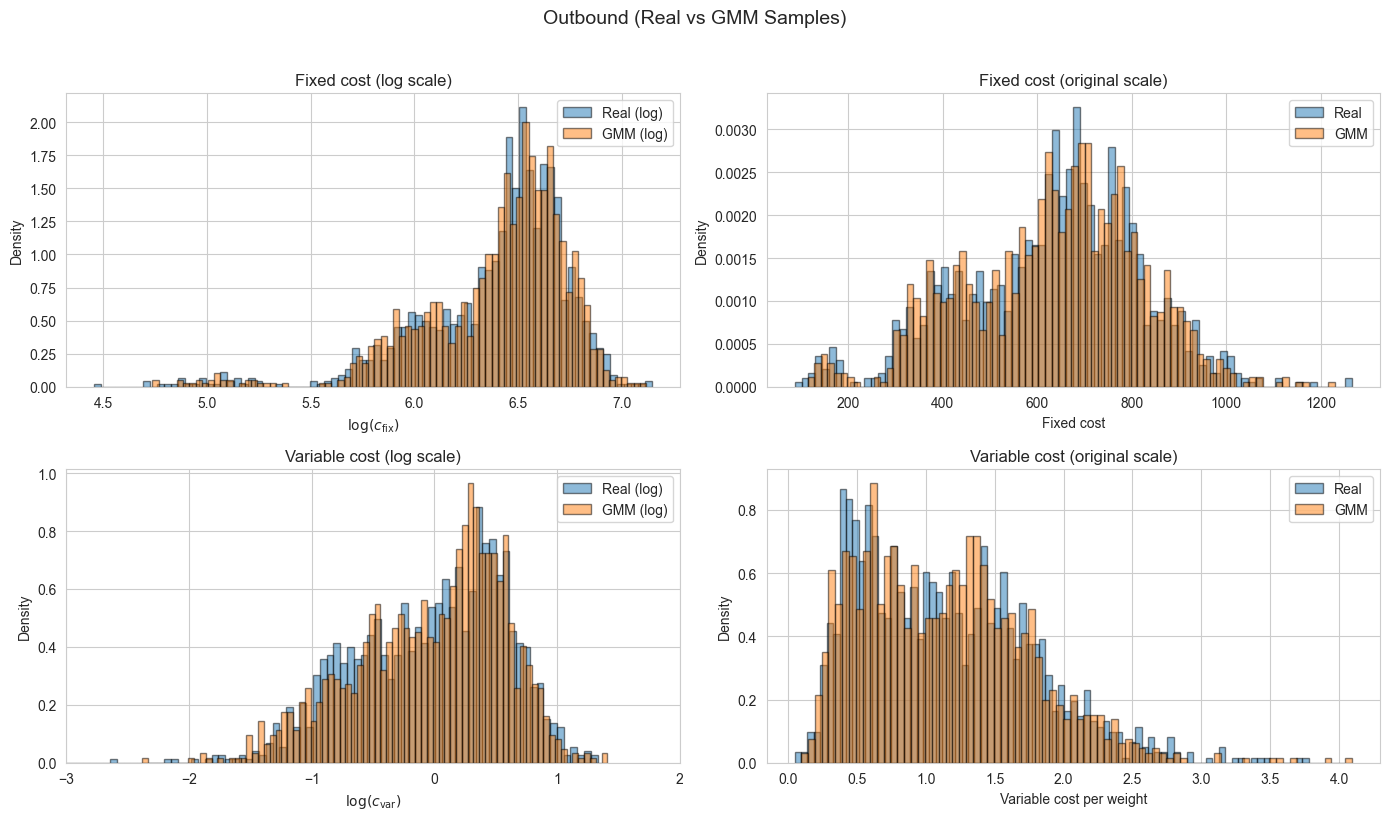

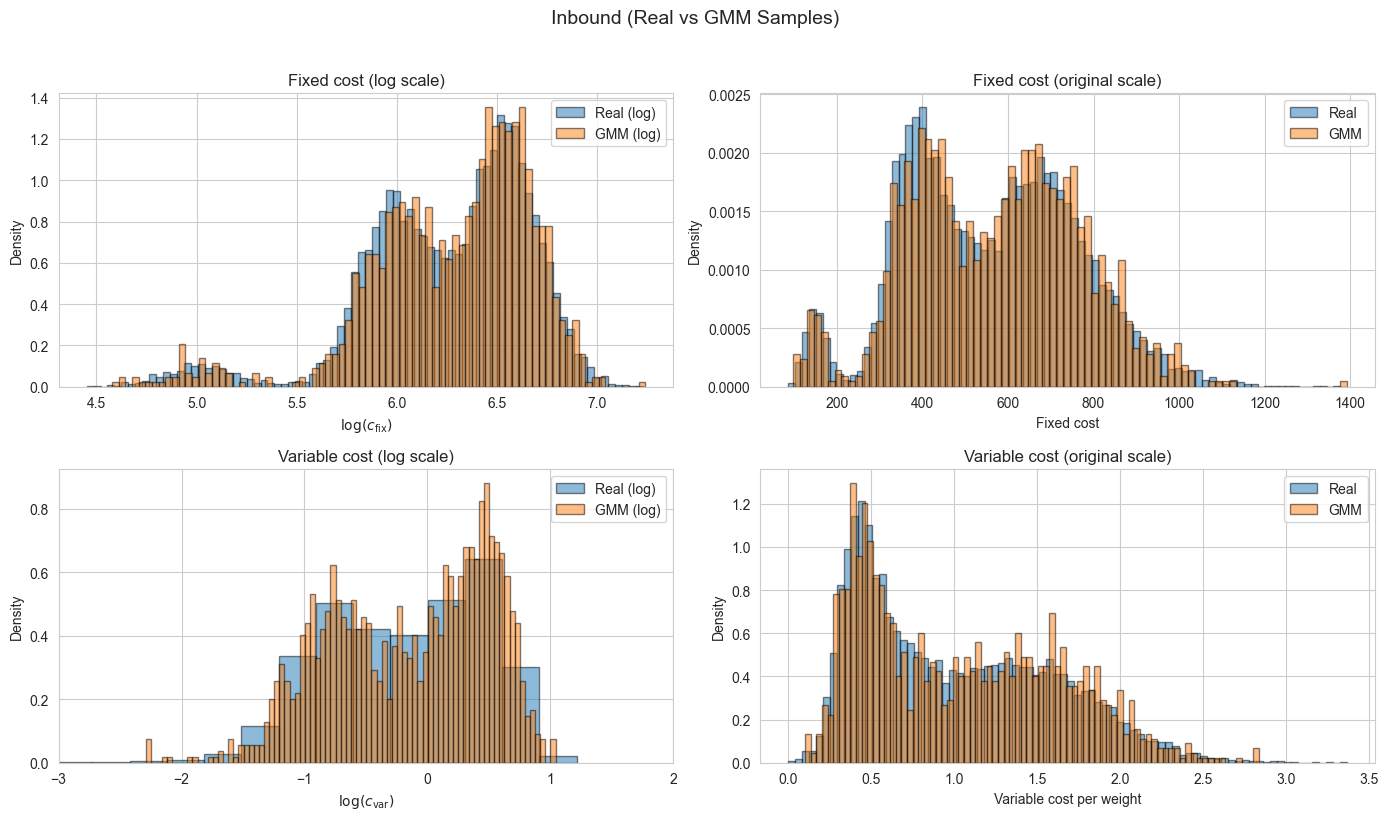

In [20]:
# HISTOGRAM OVERLAYS

# Set number of samples
n_sample = min(len(z_outbound), len(z_inbound), 50_000)

# Sample and plot results
for label, z_real, gmm in [
    ("Outbound", z_outbound, gmm_outbound),
    ("Inbound", z_inbound, gmm_inbound),
]:
    z_samp, _ = gmm.sample(n_sample)
    y_f_real, y_v_real = z_real[:, 1], z_real[:, 2]
    y_f_samp, y_v_samp = z_samp[:, 1], z_samp[:, 2]
    cf_real = np.exp(y_f_real)
    cv_real = np.exp(y_v_real)
    cf_samp = np.exp(y_f_samp)
    cv_samp = np.exp(y_v_samp)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"{label} (Real vs GMM Samples)", fontsize=14, y=1.02)

    axes[0, 0].hist(y_f_real, bins=80, density=True, alpha=0.5, label="Real (log)", edgecolor="black")
    axes[0, 0].hist(y_f_samp, bins=80, density=True, alpha=0.5, label="GMM (log)", edgecolor="black")
    axes[0, 0].set_xlabel(r"$\log(c_{\mathrm{fix}})$")
    axes[0, 0].set_ylabel("Density")
    axes[0, 0].set_title("Fixed cost (log scale)")
    axes[0, 0].legend()

    axes[0, 1].hist(cf_real, bins=80, density=True, alpha=0.5, label="Real", edgecolor="black")
    axes[0, 1].hist(cf_samp, bins=80, density=True, alpha=0.5, label="GMM", edgecolor="black")
    axes[0, 1].set_xlabel("Fixed cost")
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].set_title("Fixed cost (original scale)")
    axes[0, 1].legend()

    axes[1, 0].hist(y_v_real, bins=80, density=True, alpha=0.5, label="Real (log)", edgecolor="black")
    axes[1, 0].hist(y_v_samp, bins=80, density=True, alpha=0.5, label="GMM (log)", edgecolor="black")
    axes[1, 0].set_xlabel(r"$\log(c_{\mathrm{var}})$")
    axes[1, 0].set_xlim(-3, 2)
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].set_title("Variable cost (log scale)")
    axes[1, 0].legend()

    axes[1, 1].hist(cv_real, bins=80, density=True, alpha=0.5, label="Real", edgecolor="black")
    axes[1, 1].hist(cv_samp, bins=80, density=True, alpha=0.5, label="GMM", edgecolor="black")
    axes[1, 1].set_xlabel("Variable cost per weight")
    axes[1, 1].set_ylabel("Density")
    axes[1, 1].set_title("Variable cost (original scale)")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

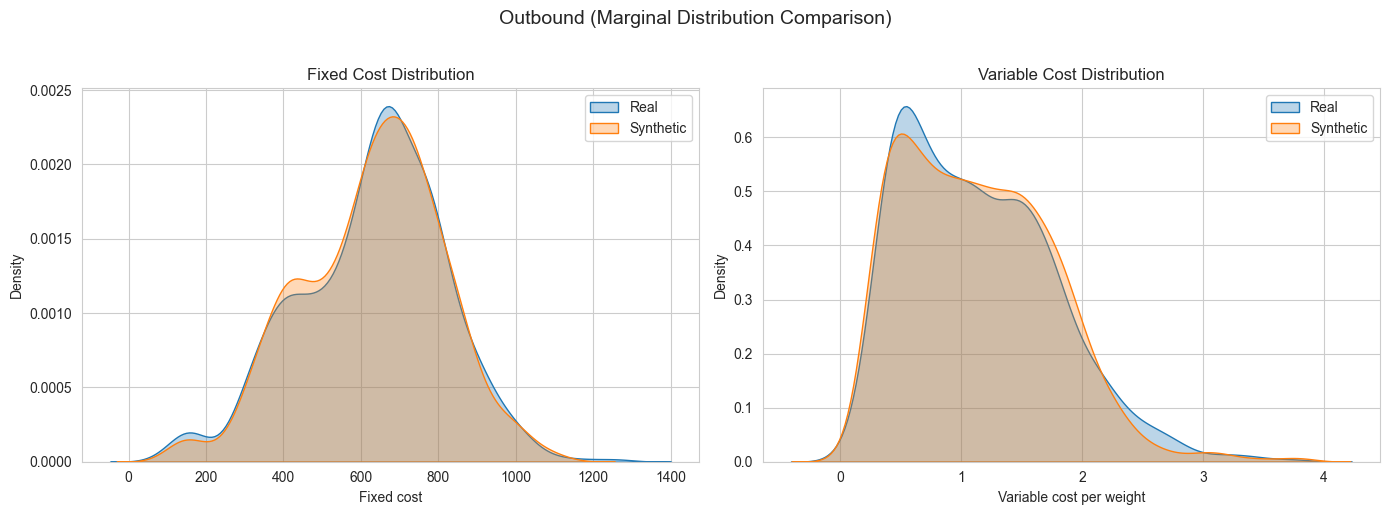

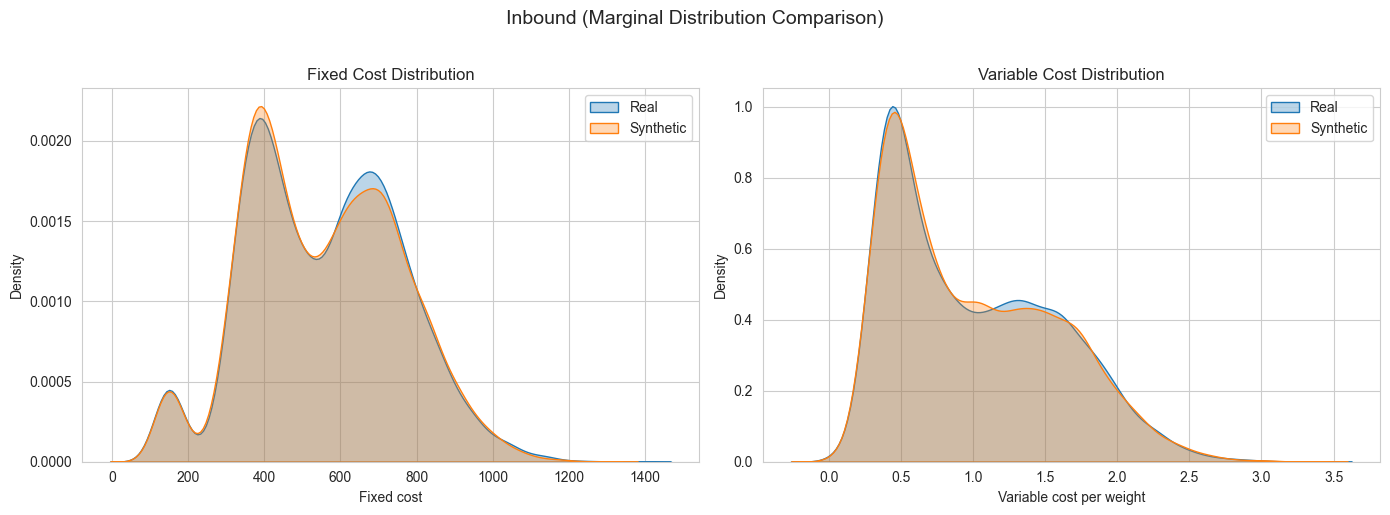

In [21]:
# KDE OVERLAY

# Sample and plot results
for label, raw_df, gmm, cl_lo, cl_hf, cl_hv in [
    ("Outbound", outbound_raw_df, gmm_outbound,
     clip_lo_out, clip_hi_fix_out, clip_hi_var_out),
    ("Inbound",  inbound_raw_df,  gmm_inbound,
     clip_lo_in,  clip_hi_fix_in,  clip_hi_var_in),
]:
    n_gen = len(raw_df)
    d_syn = rng.choice(raw_df["distance_km"].values, size=n_gen)
    cf_syn, cv_syn = sample_costs(d_syn, gmm, rng, EPS, cl_lo, cl_hf, cl_hv)

    cf_real = raw_df["fixed_costs"].values
    cv_real = raw_df["variable_costs_per_weight"].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{label} (Marginal Distribution Comparison)", fontsize=14, y=1.02)

    sns.kdeplot(cf_real, ax=axes[0], label="Real", fill=True, alpha=0.3)
    sns.kdeplot(cf_syn,  ax=axes[0], label="Synthetic", fill=True, alpha=0.3)
    axes[0].set_xlabel("Fixed cost")
    axes[0].set_title("Fixed Cost Distribution")
    axes[0].legend()

    sns.kdeplot(cv_real, ax=axes[1], label="Real", fill=True, alpha=0.3)
    sns.kdeplot(cv_syn,  ax=axes[1], label="Synthetic", fill=True, alpha=0.3)
    axes[1].set_xlabel("Variable cost per weight")
    axes[1].set_title("Variable Cost Distribution")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

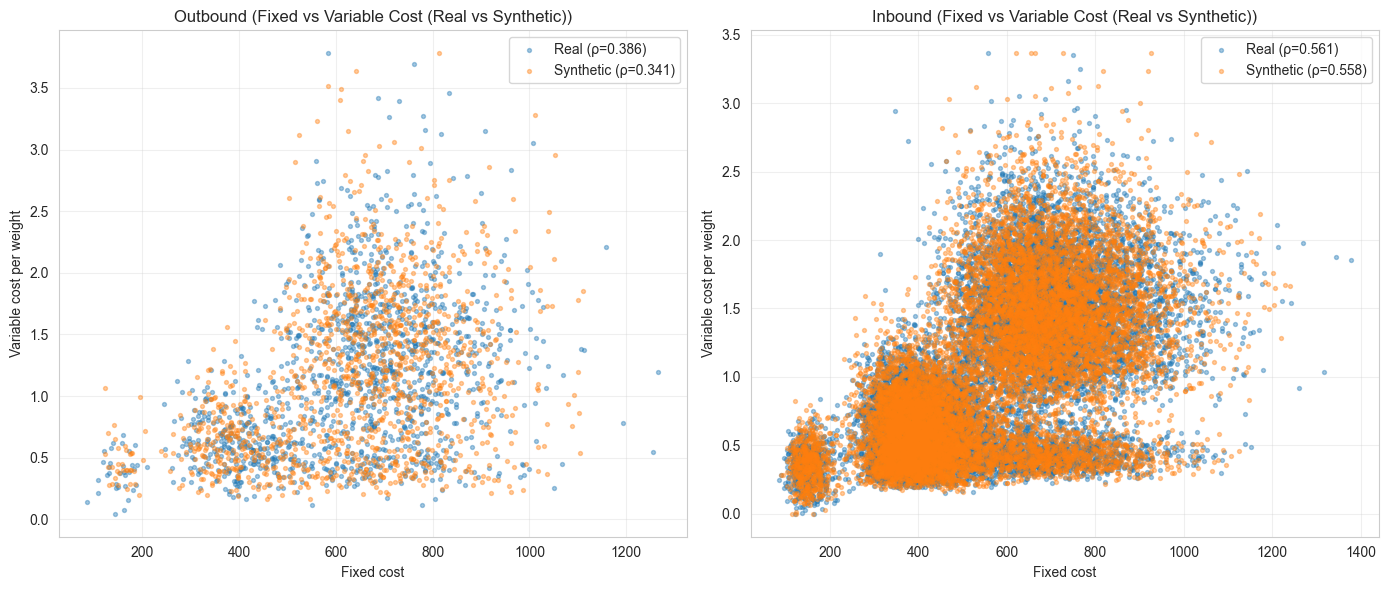

In [22]:
# SCATTERPLOT OVERLAYS

# Sample and plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (label, raw_df, gmm, cl_lo, cl_hf, cl_hv) in zip(axes, [
    ("Outbound", outbound_raw_df, gmm_outbound,
     clip_lo_out, clip_hi_fix_out, clip_hi_var_out),
    ("Inbound",  inbound_raw_df,  gmm_inbound,
     clip_lo_in,  clip_hi_fix_in,  clip_hi_var_in),
]):
    n_gen = len(raw_df)
    d_syn = rng.choice(raw_df["distance_km"].values, size=n_gen)
    cf_syn, cv_syn = sample_costs(d_syn, gmm, rng, EPS, cl_lo, cl_hf, cl_hv)

    cf_real = raw_df["fixed_costs"].values
    cv_real = raw_df["variable_costs_per_weight"].values

    r_real, _ = pearsonr(cf_real, cv_real)
    r_syn, _ = pearsonr(cf_syn, cv_syn)

    ax.scatter(cf_real, cv_real, s=8, alpha=0.4, c="C0", label=f"Real (ρ={r_real:.3f})")
    ax.scatter(cf_syn, cv_syn, s=8, alpha=0.4, c="C1", label=f"Synthetic (ρ={r_syn:.3f})")
    ax.set_xlabel("Fixed cost")
    ax.set_ylabel("Variable cost per weight")
    ax.set_title(f"{label} (Fixed vs Variable Cost (Real vs Synthetic))")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Statistical tests

We apply two-sample tests comparing generated lane costs to the real lane-cost data (separately for outbound and inbound lanes). The first three tests are univariate (1-D) and compare the marginal distribution of each cost type independently. The fourth test is bivariate (2-D) and checks whether the joint relationship between fixed and variable costs is preserved.

#### 1-D marginal tests (applied separately to fixed and variable costs)

| Test | Null hypothesis |
|------|----------------|
| **Kolmogorov–Smirnov (2-sample)** | The two samples come from the same distribution |
| **Anderson–Darling (k-sample)** | The samples come from a common unspecified distribution |
| **Cramér–von Mises (2-sample)** | The two samples come from the same distribution |

These tests compare each cost dimension in isolation. Since two distributions can pass all three 1-D tests yet still differ in their correlation structure, there is a need for a joint test.

#### 2-D joint distribution test

| Test | Null hypothesis |
|------|----------------|
| **MMD with RBF kernel (permutation)** | The two 2-D samples $(\log c_{\text{fix}},\, \log c_{\text{var}})$ come from the same joint distribution |

This test is essential because the GMM explicitly models the dependence between fixed and variable costs. Passing the 1-D tests but failing the 2-D test would indicate that while the marginals look correct, the correlation structure is not preserved.

#### MMD test procedure

The Maximum Mean Discrepancy (MMD) is a kernel-based two-sample statistic that can detect differences in arbitrary multivariate distributions.

1. **Log-transform**: Both real and synthetic costs are mapped to $(\log(c_{\text{fix}} + \varepsilon),\; \log(c_{\text{var}} + \varepsilon))$ to match the log-space in which the GMM was calibrated and to reduce scale effects.

2. **Kernel choice**: A Gaussian RBF kernel $K(a,b) = \exp\!\bigl(-\gamma\,\|a - b\|^2\bigr)$ is used. The bandwidth parameter $\gamma$ is set via the median heuristic computed on a subsample of the pooled set  $Z := X \cup Y = \{z_\ell\}_{\ell=1}^{n+m}$ (or a subsample $Z'\subset Z$):
    $$
    \sigma^2 = \operatorname{median}_{\ell\neq r}\bigl(\|z_\ell - z_r\|^2\bigr),
    \qquad
    \gamma=\frac{1}{2\sigma^2}.
    $$

3. **Unbiased MMD² estimator**: The statistic is
    $$
    \widehat{\text{MMD}}^2 = \frac{1}{n(n\!-\!1)}\!\sum_{i \neq j} K(x_i, x_j) \;+\; \frac{1}{m(m\!-\!1)}\!\sum_{i \neq j} K(y_i, y_j) \;-\; \frac{2}{nm}\!\sum_{i,j} K(x_i, y_j)
    $$
    where $\{x_i\}_{i=1}^n$ are the real samples and $\{y_j\}_{j=1}^m$ are the synthetic samples. Diagonal terms are excluded for an unbiased estimate.

4. **Permutation test**: Under $H_0$ (same distribution), the real/synthetic labels are exchangeable. We pool all $n + m$ points, randomly permute the labels 200 times, and recompute $\widehat{\text{MMD}}^2$ for each permutation. The p-value is
    $$
    p \;=\; \frac{1 + \sum_{b=1}^{B} \mathbf{1}\!\left[\mathrm{MMD}^2_{(b)} \ge \mathrm{MMD}^2_{\text{obs}}\right]}{1 + B}.
    $$
    where $B = 200$ is the number of permutations and the $+1$ terms provide standard continuity correction.

5. **Decision**: Reject $H_0$ if $p < 0.05$: evidence that the joint distribution of synthetic costs differs from the real data. Fail to reject $H_0$ if $p \geq 0.05$: no strong evidence against the claim that joint distributions are compatible. 

#### Interpretation notes

A small p-value (or large test statistic) indicates a significant difference between generated and real costs. With large sample sizes, even minor distributional differences can cause rejection — what matters is the *magnitude* of the test statistic and the practical quality of the fit, not just whether p crosses 0.05.

In [23]:
# 1D STATISTICAL TESTS (KS, AD k-sample, CvM)

# Perform tests and print results
for label, raw_df, gmm, cl_lo, cl_hf, cl_hv in [
    ("Outbound", outbound_raw_df, gmm_outbound,
     clip_lo_out, clip_hi_fix_out, clip_hi_var_out),
    ("Inbound",  inbound_raw_df,  gmm_inbound,
     clip_lo_in,  clip_hi_fix_in,  clip_hi_var_in),
]:
    # Generate synthetic sample with same size as the real sample
    n_gen = len(raw_df)
    d_syn = rng.choice(raw_df["distance_km"].values, size=n_gen)
    cf_syn, cv_syn = sample_costs(d_syn, gmm, rng, EPS, cl_lo, cl_hf, cl_hv)

    # Real samples
    cf_real = raw_df["fixed_costs"].values
    cv_real = raw_df["variable_costs_per_weight"].values

    print("-" * 55)
    print(f"Statistical Tests Results — {label}")
    print("-" * 55)

    for name, real, syn in [
        ("Fixed cost", cf_real, cf_syn),
        ("Variable cost", cv_real, cv_syn),
    ]:
        # KS (2-sample)
        ks_stat, ks_p = ks_2samp(real, syn)

        # AD (k-sample; pass as a list of samples)
        ad_res = anderson_ksamp([real, syn])
        ad_stat = float(ad_res.statistic)
        ad_p = float(ad_res.pvalue)

        # CvM (2-sample)
        cvm_res = cramervonmises_2samp(real, syn)
        cvm_stat = float(cvm_res.statistic)
        cvm_p = float(cvm_res.pvalue)

        print(f"{name}:")
        print(f"  KS statistic  = {ks_stat:.4f},  p-value = {ks_p:.4e}")
        print(f"  AD statistic  = {ad_stat:.4f},  p-value = {ad_p:.4e}")
        print(f"  CvM statistic = {cvm_stat:.4f},  p-value = {cvm_p:.4e}\n")

-------------------------------------------------------
Statistical Tests Results — Outbound
-------------------------------------------------------
Fixed cost:
  KS statistic  = 0.0435,  p-value = 1.6771e-01
  AD statistic  = 0.3098,  p-value = 2.5000e-01
  CvM statistic = 0.2092,  p-value = 2.5042e-01

Variable cost:
  KS statistic  = 0.0420,  p-value = 1.9889e-01
  AD statistic  = 0.6955,  p-value = 1.7030e-01
  CvM statistic = 0.1922,  p-value = 2.8321e-01

-------------------------------------------------------
Statistical Tests Results — Inbound
-------------------------------------------------------
Fixed cost:
  KS statistic  = 0.0109,  p-value = 4.3991e-01
  AD statistic  = -0.0865,  p-value = 2.5000e-01
  CvM statistic = 0.1822,  p-value = 3.0484e-01

Variable cost:
  KS statistic  = 0.0075,  p-value = 8.7018e-01
  AD statistic  = -0.5603,  p-value = 2.5000e-01
  CvM statistic = 0.0888,  p-value = 6.4289e-01



In [24]:
# HELPERS

def _pairwise_sq_dists(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Compute pairwise squared Euclidean distances between rows of A and B."""
    A2 = np.sum(A * A, axis=1, keepdims=True)          # (n,1)
    B2 = np.sum(B * B, axis=1, keepdims=True).T        # (1,m)
    return np.maximum(A2 + B2 - 2.0 * (A @ B.T), 0.0)

def _rbf_kernel(A: np.ndarray, B: np.ndarray, gamma: float) -> np.ndarray:
    """Gaussian RBF kernel matrix K_ij = exp(-gamma * ||A_i - B_j||^2)."""
    return np.exp(-gamma * _pairwise_sq_dists(A, B))

def _median_heuristic_gamma(X: np.ndarray, eps: float = 1e-12) -> float:
    """
    Median heuristic for RBF: sigma^2 = median(||x_i - x_j||^2), gamma = 1/(2*sigma^2).
    Uses a subsample if very large.
    """
    n = X.shape[0]
    m = min(n, 2000)
    idx = np.random.default_rng(123).choice(n, size=m, replace=False)
    Xs = X[idx]
    D2 = _pairwise_sq_dists(Xs, Xs)
    # take upper triangle distances excluding diagonal
    tri = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(tri)
    sigma2 = max(med, eps)
    return 1.0 / (2.0 * sigma2)

def mmd2_unbiased(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased estimate of MMD^2 with RBF kernel.
    """
    n = X.shape[0]
    m = Y.shape[0]
    Kxx = _rbf_kernel(X, X, gamma)
    Kyy = _rbf_kernel(Y, Y, gamma)
    Kxy = _rbf_kernel(X, Y, gamma)

    # remove diagonal terms for unbiased estimator
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_x = Kxx.sum() / (n * (n - 1))
    term_y = Kyy.sum() / (m * (m - 1))
    term_xy = Kxy.mean()

    return float(term_x + term_y - 2.0 * term_xy)

def mmd_permutation_test(
    X: np.ndarray,
    Y: np.ndarray,
    gamma: float | None = None,
    n_perm: int = 500,
    seed: int = 123,
) -> tuple[float, float]:
    """
    Permutation test for MMD^2.
    Returns: (mmd2_obs, p_value)
    """
    rng_local = np.random.default_rng(seed)
    Z = np.vstack([X, Y])
    n = X.shape[0]
    if gamma is None:
        gamma = _median_heuristic_gamma(Z)

    mmd_obs = mmd2_unbiased(X, Y, gamma)

    perm_stats = np.empty(n_perm, dtype=float)
    for b in range(n_perm):
        perm = rng_local.permutation(Z.shape[0])
        Xb = Z[perm[:n]]
        Yb = Z[perm[n:]]
        perm_stats[b] = mmd2_unbiased(Xb, Yb, gamma)

    # p-value with +1 smoothing
    pval = (1.0 + np.sum(perm_stats >= mmd_obs)) / (n_perm + 1.0)
    return mmd_obs, float(pval)

In [25]:
# 2D STATISTICAL TEST (MMD)

# Perform tests and print results
for label, raw_df, gmm, cl_lo, cl_hf, cl_hv in [
    ("Outbound", outbound_raw_df, gmm_outbound,
     clip_lo_out, clip_hi_fix_out, clip_hi_var_out),
    ("Inbound",  inbound_raw_df,  gmm_inbound,
     clip_lo_in,  clip_hi_fix_in,  clip_hi_var_in),
]:
    n_gen = len(raw_df)
    d_syn = rng.choice(raw_df["distance_km"].values, size=n_gen)
    cf_syn, cv_syn = sample_costs(d_syn, gmm, rng, EPS, cl_lo, cl_hf, cl_hv)

    cf_real = raw_df["fixed_costs"].values
    cv_real = raw_df["variable_costs_per_weight"].values

    X_real = np.column_stack([np.log(cf_real + EPS), np.log(cv_real + EPS)])
    X_syn  = np.column_stack([np.log(cf_syn  + EPS), np.log(cv_syn  + EPS)])

    # Optional: downsample for speed if huge
    max_n = 2000
    if X_real.shape[0] > max_n:
        idx = np.random.default_rng(7).choice(X_real.shape[0], size=max_n, replace=False)
        X_real = X_real[idx]
        X_syn  = X_syn[idx]

    mmd2, p = mmd_permutation_test(X_real, X_syn, gamma=None, n_perm=200, seed=42)
    verdict = "PASS (p >= 0.05)" if p >= 0.05 else "FAIL (p < 0.05)"

    print("-"*55)
    print(f"{label} Joint 2D Test (MMD, log-cost space)")
    print("-"*55)
    print(f"  MMD^2 = {mmd2:.6f}  p-value = {p:.4f}  {verdict}\n")

-------------------------------------------------------
Outbound Joint 2D Test (MMD, log-cost space)
-------------------------------------------------------
  MMD^2 = -0.000378  p-value = 0.8259  PASS (p >= 0.05)

-------------------------------------------------------
Inbound Joint 2D Test (MMD, log-cost space)
-------------------------------------------------------
  MMD^2 = 0.000296  p-value = 0.2139  PASS (p >= 0.05)



### 7.4 End-to-end generation using pre-computed distances

We now use the pre-computed outbound and inbound distances from the configuration
to generate the full cost structure for the synthetic network and compare it to the real data. Moreover, we investigate generation stability based on different seeds. 

In [28]:
# END-TO-END GENERATION

# Outbound costs
cf_out_gen, cv_out_gen = sample_costs(
    outbound_distances.ravel(), gmm_outbound, rng, EPS,
    clip_lo_out, clip_hi_fix_out, clip_hi_var_out
)
outbound_fixed    = cf_out_gen.reshape(n_warehouses, n_regions)
outbound_variable = cv_out_gen.reshape(n_warehouses, n_regions)

# Inbound costs
cf_in_gen, cv_in_gen = sample_costs(
    inbound_distances.ravel(), gmm_inbound, rng, EPS,
    clip_lo_in, clip_hi_fix_in, clip_hi_var_in
)
inbound_fixed    = cf_in_gen.reshape(n_warehouses, n_skus)
inbound_variable = cv_in_gen.reshape(n_warehouses, n_skus)

# Store results
cost_structure = {
    "outbound_fixed":    outbound_fixed,
    "outbound_variable": outbound_variable,
    "outbound_distances": outbound_distances,
    "inbound_fixed":     inbound_fixed,
    "inbound_variable":  inbound_variable,
    "inbound_distances":  inbound_distances,
}

# Define real-synthetic pairs
pairs = [
    ("Outbound fixed",    outbound_raw_df["fixed_costs"].values,               outbound_fixed.ravel()),
    ("Outbound variable", outbound_raw_df["variable_costs_per_weight"].values,  outbound_variable.ravel()),
    ("Inbound fixed",     inbound_raw_df["fixed_costs"].values,                inbound_fixed.ravel()),
    ("Inbound variable",  inbound_raw_df["variable_costs_per_weight"].values,   inbound_variable.ravel()),
]

# Print results
print("-"*85)
print(f"Generated cost structure ({n_warehouses} Warehouses, {n_skus} SKUs, {n_regions} Regions)")
print("-"*85)
for key, arr in cost_structure.items():
    print(f"  {key:>22s}: shape={str(arr.shape)}  "
          f"min={arr.min():.4f}  max={arr.max():.4f}  mean={arr.mean():.4f}")

print("\n")
print("-" * 85)
print("Cost Range Comparison (Generated vs Real)")
print("-" * 85)
print(f"  {'':>22s} {'Real [P5, P95]':>25s} {'Generated [P5, P95]':>24s}  {'Overlap':>8s}")

for name, real, gen in pairs:
    r_lo, r_hi = np.percentile(real, [5, 95])
    g_lo, g_hi = np.percentile(gen,  [5, 95])
    overlap = max(0, min(r_hi, g_hi) - max(r_lo, g_lo)) / (r_hi - r_lo) * 100
    print(f"{name:>25s} [{r_lo:>10.4f}, {r_hi:>10.4f}] [{g_lo:>10.4f}, {g_hi:>10.4f}]  {overlap:>6.1f}%")

-------------------------------------------------------------------------------------
Generated cost structure (10 Warehouses, 10 SKUs, 10 Regions)
-------------------------------------------------------------------------------------
          outbound_fixed: shape=(10, 10)  min=154.0640  max=1023.3389  mean=617.4556
       outbound_variable: shape=(10, 10)  min=0.1505  max=3.3083  mean=0.9901
      outbound_distances: shape=(10, 10)  min=239.6757  max=17200.9596  mean=4664.0672
           inbound_fixed: shape=(10, 10)  min=131.8486  max=944.3270  mean=498.9762
        inbound_variable: shape=(10, 10)  min=0.2415  max=2.6464  mean=0.7804
       inbound_distances: shape=(10, 10)  min=282.2681  max=10111.5105  mean=3048.4033


-------------------------------------------------------------------------------------
Cost Range Comparison (Generated vs Real)
-------------------------------------------------------------------------------------
                                    Real [P5, P95] 

In [29]:
# SAMPLING STABILITY TEST

# Set parameters
n_trials = 20
means = {key: [] for key in ["outbound_fixed", "outbound_variable",
                               "inbound_fixed", "inbound_variable"]}

# Sample n_trials times
for trial in range(n_trials):
    trial_rng = np.random.default_rng(SEED + trial)

    cf_o, cv_o = sample_costs(
        outbound_distances.ravel(), gmm_outbound, trial_rng, EPS,
        clip_lo_out, clip_hi_fix_out, clip_hi_var_out
    )
    cf_i, cv_i = sample_costs(
        inbound_distances.ravel(), gmm_inbound, trial_rng, EPS,
        clip_lo_in, clip_hi_fix_in, clip_hi_var_in
    )

    means["outbound_fixed"].append(cf_o.mean())
    means["outbound_variable"].append(cv_o.mean())
    means["inbound_fixed"].append(cf_i.mean())
    means["inbound_variable"].append(cv_i.mean())


# Print results
print("-"*70)
print(f"Stability Over {n_trials} Independent Samplings")
print("-"*70)
print(f"  {'Cost component':>25s} {'Mean of means':>15s} {'Std of means':>15s} {'CV (%)':>10s}")
for key in means:
    arr = np.array(means[key])
    m, s = arr.mean(), arr.std()
    cv = s / m * 100 if m > 0 else 0
    print(f"  {key:>25s} {m:>15.4f} {s:>15.4f} {cv:>10.2f}")

----------------------------------------------------------------------
Stability Over 20 Independent Samplings
----------------------------------------------------------------------
             Cost component   Mean of means    Std of means     CV (%)
             outbound_fixed        615.5481         14.2270       2.31
          outbound_variable          0.9669          0.0172       1.78
              inbound_fixed        509.3285         11.6705       2.29
           inbound_variable          0.7809          0.0182       2.33


## 8. Save Outputs for Downstream Pipelines

Save the cost matrices so they can be loaded by `order_generator.ipynb` and other downstream notebooks.

In [30]:
# SAVE OUTPUTS

outputs_dir = Path("outputs/intermediate")
outputs_dir.mkdir(parents=True, exist_ok=True)

out_path = outputs_dir / f"costs_n{n_regions}_w{n_warehouses}_s{n_skus}.npz"
np.savez(
    out_path,
    outbound_costs_fixed=outbound_fixed,
    outbound_costs_variable=outbound_variable,
    inbound_costs_fixed=inbound_fixed,
    inbound_costs_variable=inbound_variable,
)

print(f"Saved to {out_path}")
print(f"  outbound_costs_fixed:    {outbound_fixed.shape}")
print(f"  outbound_costs_variable: {outbound_variable.shape}")
print(f"  inbound_costs_fixed:     {inbound_fixed.shape}")
print(f"  inbound_costs_variable:  {inbound_variable.shape}")

Saved to outputs\intermediate\costs_n10_w10_s10.npz
  outbound_costs_fixed:    (10, 10)
  outbound_costs_variable: (10, 10)
  inbound_costs_fixed:     (10, 10)
  inbound_costs_variable:  (10, 10)
